## Examples: Build all the classifiers!

#### In this notebook, we will explore building multiple types of classification models for the MBTI dataset and evaluate their performance using cross-validation

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Build multiple types of classification models.
#### - Evaluate the performance of each model using cross-validation.
#### - Determine which model performs best for the MBTI dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import ListedColormap

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [2]:
## Read the data
print('Reading the data into Pandas DF...')
mbti = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/classification_sprint/mbti_train.csv')

mbti.head()

Reading the data into Pandas DF...


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [3]:
## split the rows
# Separate each post in the 'posts' column into individual rows and create a new dataframe
print('Separating data...')
all_mbti = []
for i, row in mbti.iterrows():
    for post in row['posts'].split('|||'):
        all_mbti.append([row['type'], post])
all_mbti = pd.DataFrame(all_mbti, columns=['type', 'post'])

## Remove urls
# Replace URLs in the 'post' column with a generic label
print('Removing URLs...')
pattern_url = r'http[s]?://(?:[A-Za-z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9A-Fa-f][0-9A-Fa-f]))+'
subs_url = r'url-web'
all_mbti['post'] = all_mbti['post'].replace(to_replace=pattern_url, value=subs_url, regex=True)

# Make lower case
# Convert all text in the 'post' column to lowercase
print('Lowering case...')
all_mbti['post'] = all_mbti['post'].str.lower()

# Remove punctuation
# Define a function to remove punctuation and numbers from the 'post' column
import string
print('Claening punctuation...')
def remove_punctuation_numbers(post):
    punc_numbers = string.punctuation + '0123456789'
    return ''.join([l for l in post if l not in punc_numbers])

# Apply the remove_punctuation_numbers function to the 'post' column
all_mbti['post'] = all_mbti['post'].apply(remove_punctuation_numbers)

Separating data...
Removing URLs...
Lowering case...
Claening punctuation...


In [4]:
# Extract the first letter of the 'type' column to determine if the person is introverted (I) or not
all_mbti['I'] = all_mbti['type'].apply(lambda x: x[0] == 'I').astype('int')

# Assign the target variable to 'y'
y = all_mbti['I']
y.shape

(316548,)

In [5]:
vect = CountVectorizer(stop_words='english', min_df=.01)
X = vect.fit_transform(all_mbti['post'])

In [6]:
n = 5000

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X[:n].toarray(),
    y[:n]
)

### Let's build some classification models

In [7]:
# Define the names of the classifiers
names = [
    'Logistic Regression', 'Nearest Neighbors', 'Linear SVM', 'RBF SVM',
    'Decision Tree', 'Random Forest', 'AdaBoost'
]

In [8]:
# Define the classifiers with their respective hyperparameters
classifiers = [
    LogisticRegression(),
    KNeighborsClassifier(3),
    SVC(kernel='linear', C=0.025),
    SVC(gamma=2, C=1),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    AdaBoostClassifier()
]

In [9]:
# Empy lists to store results
results = [] # Store evaluation metrics for each classifier
models = {} # Store trained models
confusion = {} # Store confusion matrices for each classifier
class_report = {} # Store classification reports for each classifier

# Iterate over each classifier
for name, clf in zip(names, classifiers):
    print('Fitting {:s} model...'.format(name))
    # Measure the time taken to fit the model
    run_time = %timeit -q -o clf.fit(X_train, y_train)

    print('... Predicting')
    # Predict on the training data
    y_pred = clf.predict(X_train)

    if name in set(['AdaBoost', 'RBF SVM']):
        print(name)
        print('Actual: ', np.bincount(y_train))
        print('Predicted: ', np.bincount(y_pred))
    
    y_pred_test = clf.predict(X_test)

    print('... Scoring')
    # Calculate evaluation metrics
    accuracy = metrics.accuracy_score(y_train, y_pred)
    precision = metrics.precision_score(y_train, y_pred)
    recall = metrics.recall_score(y_train, y_pred)

    f1 = metrics.f1_score(y_train, y_pred)
    f1_test = metrics.f1_score(y_test, y_pred_test)

    # Save the results to dictionaries
    models[name] = clf
    confusion[name] = metrics.confusion_matrix(y_train, y_pred)
    class_report[name] = metrics.classification_report(y_train, y_pred)

    # Append results to the lost
    results.append([name, accuracy, precision, recall, f1, f1_test, run_time.best])

# Convert results to dataframe for easy visualisation
results = pd.DataFrame(results, columns=['Classifier', 'Accuracy', 'Precision', 'Recall', 'F1 Train', 'F1 Test', 'Train Time'])
results.set_index('Classifier', inplace=True)

print('... All done!')

Fitting Logistic Regression model...
... Predicting
... Scoring
Fitting Nearest Neighbors model...
... Predicting
... Scoring
Fitting Linear SVM model...
... Predicting
... Scoring
Fitting RBF SVM model...


D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

... Predicting
RBF SVM
Actual:  [ 735 3015]
Predicted:  [ 586 3164]
... Scoring
Fitting Decision Tree model...
... Predicting
... Scoring
Fitting Random Forest model...
... Predicting
... Scoring
Fitting AdaBoost model...


D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

... Predicting
AdaBoost
Actual:  [ 735 3015]
Predicted:  [   0 3750]
... Scoring
... All done!


D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [10]:
results.sort_values('F1 Train', ascending=False)

,Accuracy,Precision,Recall,F1 Train,F1 Test,Train Time
Classifier,,,,,,
RBF SVM,0.956533,0.950695,0.997678,0.973620,0.883973,1.169073
Nearest Neighbors,0.834667,0.855236,0.956219,0.902913,0.839753,0.001302
Decision Tree,0.811467,0.812398,0.995357,0.894619,0.879170,0.022063
Random Forest,0.804000,0.804000,1.000000,0.891353,0.881432,0.020669
Linear SVM,0.804000,0.804000,1.000000,0.891353,0.881432,0.541079
AdaBoost,0.804000,0.804000,1.000000,0.891353,0.881432,0.417904
Logistic Regression,0.804267,0.806339,0.995688,0.891066,0.881508,0.025760


Text(0.5, 1.0, 'Training Time vs. Classifier')

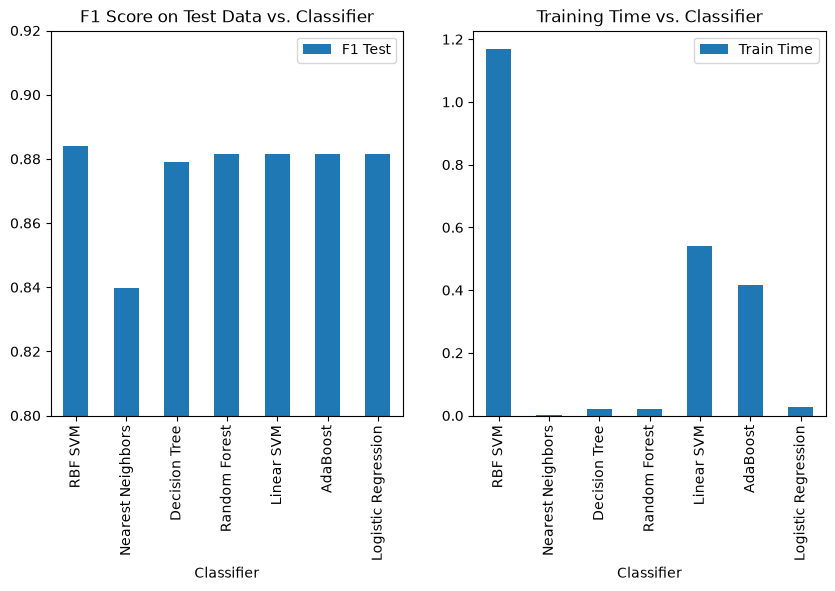

In [14]:
# plot F1 score on Test Data vs. Classifier
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
results.sort_values('F1 Train', ascending=False, inplace=True)
results.plot(y=['F1 Test'], kind='bar', ax=ax[0], xlim=[0, 1.1], ylim=[0.80, 0.92])
ax[0].set_title('F1 Score on Test Data vs. Classifier')
results.plot(y='Train Time', kind='bar', ax=ax[1])
ax[1].set_title('Training Time vs. Classifier')

In [15]:
# Display confusion matrices and classification reports
for name, matrix in confusion.items():
    print(f"Confusion Matrix for {name}:")
    print(matrix)
    print()


for name, report in class_report.items():
    print(f"Classification Report for {name}:")
    print(report)
    print()

Confusion Matrix for Logistic Regression:
[[  14  721]
 [  13 3002]]

Confusion Matrix for Nearest Neighbors:
[[ 247  488]
 [ 132 2883]]

Confusion Matrix for Linear SVM:
[[   0  735]
 [   0 3015]]

Confusion Matrix for RBF SVM:
[[ 579  156]
 [   7 3008]]

Confusion Matrix for Decision Tree:
[[  42  693]
 [  14 3001]]

Confusion Matrix for Random Forest:
[[   0  735]
 [   0 3015]]

Confusion Matrix for AdaBoost:
[[   0  735]
 [   0 3015]]

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.52      0.02      0.04       735
           1       0.81      1.00      0.89      3015

    accuracy                           0.80      3750
   macro avg       0.66      0.51      0.46      3750
weighted avg       0.75      0.80      0.72      3750


Classification Report for Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.65      0.34      0.44       735
           1       0.86    

### Model Validation

#### But how do we know if these models are robust?

#### Model validation is the process of checking if our model produces reliable results. In order to make an informed choice, we need a way to validate the our model and our hyperparameters are a good fit to the data

### K-Fold Cross Validation

In [16]:
# Retrieve the trained Logistic Regression model from the 'models' dictionary
model = models['Logistic Regression']

# Perform k-fold cross-validation on the Logistic Regression model
# using the entire dataset (first n samples) and the target variable y
# Print the cross-validation scores
print(cross_val_score(model, X[:n].toarray(), y[:n]))

[0.799 0.794 0.788 0.798 0.799]


In [21]:
# initialise an empty list to store cross-validation results
cv = []

# Iterate over each model in the 'models' dictionary
for name, model in models.items():
    print() # print an empty line for better readability
    print(name) # Print the name of the current model
    # Perform k-fold cross-validation (with k=10) on the current model
    scores = cross_val_score(model, X=X[:n].toarray(), y=y[:n], cv=10)
    # Calculate the mean and standard deviation of the cross-validation scores
    print("Accuracy: {:0.2f} (+/- {:0.4f})".format(scores.mean(), scores.std()))
    # Append the model name, mean cross-validation results to a DataFrame
    cv.append([name, scores.mean(), scores.std()])

# Convert the list of cross-validation results to a DataFrame
cv = pd.DataFrame(cv, columns=['Model', 'CV_Mean', 'CV_Std_Dev'])

# Set the index of the DataFrame to the model names
cv.set_index('Model', inplace=True)


Logistic Regression
Accuracy: 0.80 (+/- 0.0051)

Nearest Neighbors
Accuracy: 0.70 (+/- 0.0401)

Linear SVM
Accuracy: 0.80 (+/- 0.0000)

RBF SVM
Accuracy: 0.80 (+/- 0.0076)

Decision Tree
Accuracy: 0.79 (+/- 0.0038)

Random Forest
Accuracy: 0.80 (+/- 0.0000)

AdaBoost
Accuracy: 0.80 (+/- 0.0000)


In [22]:
cv

,CV_Mean,CV_Std_Dev
Model,,
Logistic Regression,0.7952,0.005075
Nearest Neighbors,0.7030,0.040072
Linear SVM,0.8000,0.000000
RBF SVM,0.7968,0.007600
Decision Tree,0.7934,0.003800
Random Forest,0.8000,0.000000
AdaBoost,0.8000,0.000000


<Axes: xlabel='Model'>

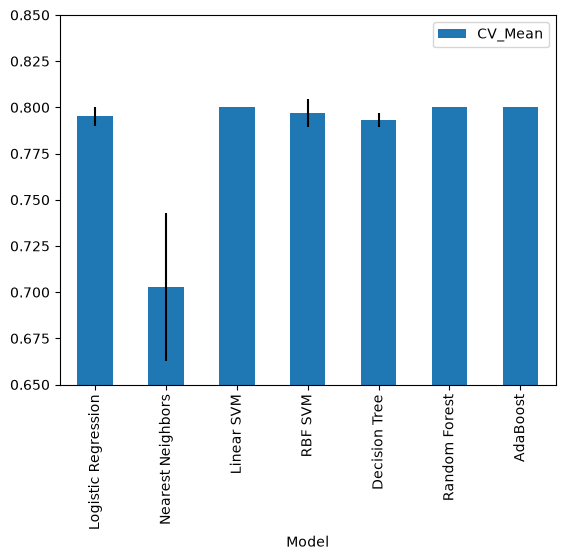

In [23]:
# Plot the mean cross-validation scores with error bars representing the standard deviation
# Set the y-axis to represent the mean cross-validation scores
# Set the error bars to represent the standard deviation of the cross-validation scores
# Limit the y-axis to the range [0.65, 0.85] for better visualization
cv.plot(y='CV_Mean', yerr='CV_Std_Dev', kind='bar', ylim=[0.65, 0.85])